<a href="https://colab.research.google.com/github/prasad2154/NewVision/blob/main/GENAI/7_cosine_similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparing Text with Cosine Similarity

We learned that embeddings convert text into vectors.

But how do we actually **compare** two vectors to see if texts are similar?

That's where **cosine similarity** comes in.

**Cosine similarity measures the similarity between two non-zero vectors by calculating the cosine of the angle between them, producing a value between -1 and 1.**

>A cosine similarity of 1 indicates that the vectors point in the same direction, 0 indicates they are orthogonal (no similarity), and -1 indicates they point in opposite directions. This makes it particularly useful in high-dimensional spaces, such as text data represented as word vectors, where traditional distance metrics may be less effective.

### **What is cosine similarity:** https://chatgpt.com/share/6a0c6055-a9b8-83a4-b1d4-9bbf768f2787

## Setup

In [1]:
from google import genai
import os
from dotenv import load_dotenv
import numpy as np

load_dotenv(dotenv_path='./.env')
API_KEY = os.environ["GEMINI_API_KEY"]
# from google.colab import userdata
# API_KEY = userdata.get('GEMINI_API_KEY')

client = genai.Client(api_key=API_KEY)

## Comparing Two Texts

Let's take two sentences that mean the same thing but use different words.

In [2]:
ex = client.models.embed_content(model="gemini-embedding-001", contents='sarita is going to market').embeddings[0].values
print(ex)
print('Len:',len(ex))

[-0.02093432, -0.009490365, 0.0061912397, -0.07786916, 0.004825494, -0.0146017475, 0.0027808605, 0.028528312, 0.0036135034, 0.005464228, -0.004824684, 0.0064500156, -0.016204482, -0.016872585, 0.13208695, 0.0040241117, -0.014492425, -0.010974795, 0.018205756, -0.0076349564, -0.004922356, 0.016697753, 0.00611764, 0.0063072983, 0.01254132, -0.0033589806, 0.0009363979, 0.015666047, 0.01395623, -0.0025869221, 0.035108034, -0.003683613, -0.017468529, 0.010007081, 0.010485671, 0.008327121, 0.02573517, 0.0048025884, 0.016740406, 0.001304317, 0.0066684396, -0.00723912, 0.00039872283, -0.0012951146, -0.0056809257, -0.0023948743, 0.023333523, -0.008465623, -0.008456968, 0.046316084, -0.008829452, -0.012461213, -0.00225836, -0.17946152, -0.0018513083, 0.0033058114, 0.0026788577, -0.021967547, 0.0011215488, 0.0042503597, -0.017493002, 0.025673563, 0.0079752905, 0.018078286, -0.01726107, -0.009063439, 0.009286456, -0.015370412, -0.0056908787, 0.02711372, 0.001485073, -0.019021068, 0.008392736, 0.01

In [3]:
ex2 = client.models.embed_content(model="gemini-embedding-001", contents='s').embeddings[0].values
print(ex2)
print('Len:',len(ex2))

[-0.0051922407, 0.007693809, 0.012696172, -0.06838176, -0.014026419, -0.011197688, 0.002728666, 0.02231244, 0.015873218, 0.017744003, 0.017257158, -9.75983e-05, -0.0068683126, 0.030899577, 0.108596556, -0.0034644054, 0.010909491, -0.008645613, 0.011129773, -0.010395976, 0.024510115, -0.01779472, 0.005054873, -0.004551637, 0.011676203, -0.020132868, 0.007983106, -0.028240873, 0.040595043, 0.008349991, 0.011622661, 0.019242615, -0.004663392, 0.01635968, 0.010869793, 0.0033556998, 0.009088653, -0.012409952, -0.021506116, 0.0085077295, 0.024122776, 0.008255627, 0.020960838, -0.011646507, -0.009302788, -0.0072319116, -0.0032153735, -0.006733941, -0.02299398, 0.025188277, 0.013724386, -0.027650023, -0.039983407, -0.15054873, 0.0034522144, -0.022640787, -0.032058243, -0.016182516, 0.0174346, 0.01743349, -0.022707004, 0.0020738733, -0.007695695, -0.005950824, -0.023447035, 0.010595922, 0.013052962, 0.007049416, -0.011383841, 0.016359482, 0.0043354775, 0.012596199, -0.01110748, 0.006443157, 0.0

In [13]:
text_a = "The sun shines brightly in the sky."
text_b = "She reads a book every single day"

# Get embeddings
emb_a = client.models.embed_content(model="gemini-embedding-001", contents=text_a).embeddings[0].values
emb_b = client.models.embed_content(model="gemini-embedding-001", contents=text_b).embeddings[0].values

print(f"Text A: '{text_a}'",emb_a)
print(f"Text B: '{text_b}'",emb_b)
print(f"\nBoth have {len(emb_a)} dimensions")

Text A: 'The sun shines brightly in the sky.' [-0.00765817, 0.02086973, 0.009165813, -0.066271484, -0.03519589, 0.02649138, 0.009016257, -0.0012945458, -0.0044100536, 0.017109012, -0.013153341, -0.0057527004, -0.019448766, 0.0014668545, 0.112080224, -0.02007723, -0.008860018, -0.0027126272, 0.010365772, -0.010655852, -0.003209597, -0.019762486, 0.02956899, -0.025047537, -0.003616694, -0.011680155, 0.01743977, -0.0018772604, 0.032817032, -0.0038919346, 0.020233572, 0.0059498465, -0.0032704847, -0.014670274, -0.013119133, 0.008491938, 0.046668462, 0.032560248, 0.012295101, -0.014829466, -0.03121162, 0.011238053, -0.019512527, -0.03166548, 0.014976014, -0.0018078976, -0.00508542, -0.0150958495, 0.015996775, 0.007303702, -0.026651504, -0.008631002, -0.00016538586, -0.16944598, -0.019782681, 0.03382879, 0.003644262, 0.010306871, 0.008363944, -0.020955777, 0.016166713, 0.019051803, 0.0004033015, -0.032497868, -0.010169805, -0.027728142, -0.0075990832, -0.007173699, 0.006276664, 0.017773807, 

In [14]:
def cosine_similarity(vec1, vec2):
    vec1 = np.array(vec1)
    vec2 = np.array(vec2)
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

similarity = cosine_similarity(emb_a, emb_b)
print(f"Similarity between A and B: {similarity:.4f}")

Similarity between A and B: 0.6065


## What is Cosine Similarity?

**Cosine similarity** measures the angle between two vectors:

- `1.0` = identical direction (same meaning)
- `0.0` = perpendicular (unrelated)
- `-1.0` = opposite direction (rare in practice)

Formula: `cos(θ) = (A · B) / (||A|| × ||B||)`

- Dot product of the vectors
- Divided by the product of their magnitudes

## Similar vs Different Texts

Let's compare sentences with similar meaning vs completely different topics.

In [18]:
# sentences = [
#     "The domestic cat is a small, carnivorous mammal that often catches mice.",
#     "A pet cat is a small carnivorous animal that frequently hunts mice",
#     "Quantum computing utilizes qubits to perform complex calculations at unprecedented speeds"
# ]
sentences=[
    "The weather is very hot today.",
    "The temperature is extremely high right now",
    "I Like Python"]
# Generate embeddings
embeddings = []
for s in sentences:
    emb = client.models.embed_content(model="gemini-embedding-001", contents=s).embeddings[0].values
    embeddings.append(emb)

# Compare
print("Comparing sentences:\n")
print(f"1: '{sentences[0]}'")
print(f"2: '{sentences[1]}'")
print(f"3: '{sentences[2]}'")

print(f"\n1 vs 2 (similar meaning): {cosine_similarity(embeddings[0], embeddings[1]):.4f}")
print(f"1 vs 3 (different topic):  {cosine_similarity(embeddings[0], embeddings[2]):.4f}")

Comparing sentences:

1: 'The weather is very hot today.'
2: 'The temperature is extremely high right now'
3: 'I Like Python'

1 vs 2 (similar meaning): 0.8034
1 vs 3 (different topic):  0.5377


## Why This Matters

Cosine similarity is the foundation of:

1. **Semantic Search** — Find documents by meaning, not keywords
2. **Duplicate Detection** — Find similar content
3. **Clustering** — Group related documents
4. **RAG Systems** — Retrieve relevant context for LLMs

---

## Key Takeaways

1. **Cosine similarity** measures how similar two vectors are
2. Score of **1.0** = identical meaning, **0.0** = unrelated
3. Texts with **same meaning but different words** score high
4. Texts about **different topics** score low

---



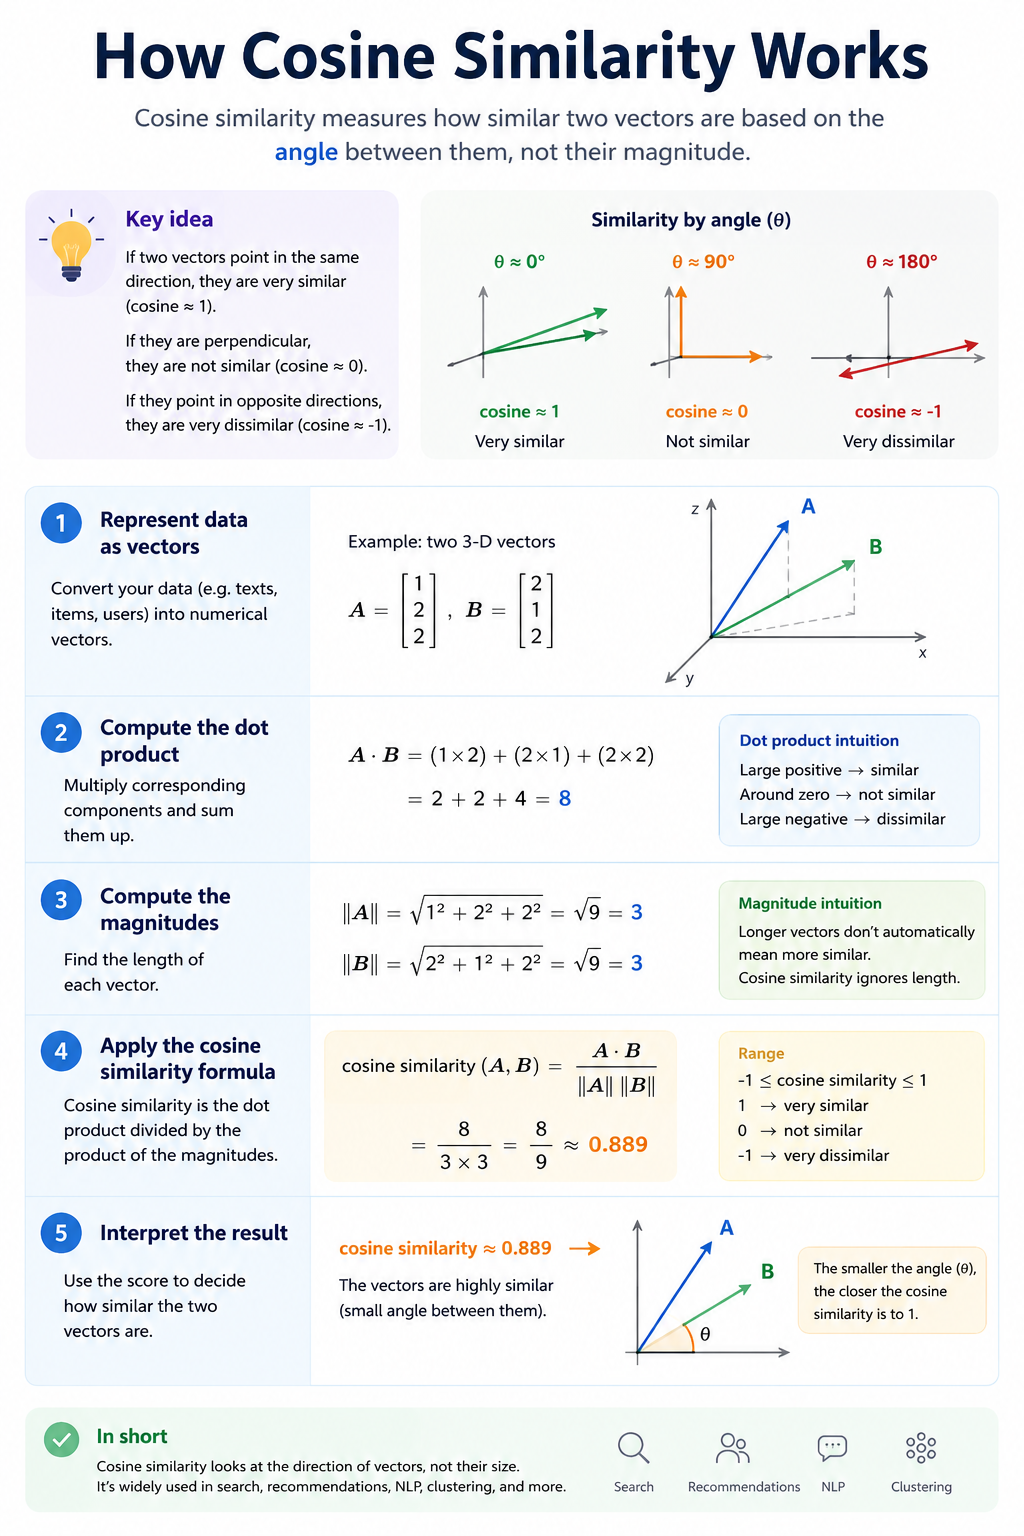